In [1]:
import requests

def stats_genoma(accession):
    url = f"https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/accession/{accession}/dataset_report"
    r = requests.get(url)
    r.raise_for_status()
    data = r.json()
    reporte = data["reports"][0]
    stats = reporte["assembly_stats"]
    return {
        "accession": accession,
        "tamaño_mb": int(stats["total_sequence_length"]) / 1_000_000,
        "gc_percent": stats.get("gc_percent"),
    }

cepas = {
    "090104": "GCA_000466825.2",
    "DSM 44287": "GCA_000688415.1",
    "CD1121": "GCA_023509255.1",
}

for cepa, acc in cepas.items():
    print(cepa, stats_genoma(acc))

090104 {'accession': 'GCA_000466825.2', 'tamaño_mb': 2.328061, 'gc_percent': 55.5}
DSM 44287 {'accession': 'GCA_000688415.1', 'tamaño_mb': 2.261008, 'gc_percent': 55.5}
CD1121 {'accession': 'GCA_023509255.1', 'tamaño_mb': 2.374277, 'gc_percent': 55.5}


In [2]:
url = "https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/taxon/Corynebacterium%20pseudodiphtheriticum/dataset_report"
params = {"page_size": 100}
r = requests.get(url, params=params)
r.raise_for_status()
data = r.json()

print("Total de genomas depositados hoy:", data["total_count"])

Total de genomas depositados hoy: 159


In [3]:
url = "https://api.ncbi.nlm.nih.gov/datasets/v2alpha/genome/taxon/Corynebacterium%20pseudodiphtheriticum/dataset_report"
params = {"page_size": 200}
r = requests.get(url, params=params)
r.raise_for_status()
data = r.json()

reportes = data["reports"]
print("Cantidad de reportes recibidos:", len(reportes))
print(reportes[0]["assembly_info"])

Cantidad de reportes recibidos: 159
{'assembly_level': 'Complete Genome', 'assembly_status': 'current', 'paired_assembly': {'accession': 'GCF_023509295.1', 'status': 'current', 'annotation_name': 'GCF_023509295.1-RS_2026_05_25'}, 'assembly_name': 'ASM2350929v1', 'assembly_type': 'haploid', 'bioproject_lineage': [{'bioprojects': [{'accession': 'PRJNA541851', 'title': 'Whole genome sequencing of Corynebacterium isolated from Forcibly Displaced Myanmar Nationals'}]}], 'bioproject_accession': 'PRJNA541851', 'release_date': '2022-05-19', 'submitter': 'Divison of Bacterial Diseases, Centers for Disease Control', 'refseq_category': 'reference genome', 'sequencing_tech': 'PacBio Sequel II; Illumina MiSeq', 'assembly_method': 'FLYE v. unspecified', 'biosample': {'accession': 'SAMN24898280', 'last_updated': '2022-02-02T09:55:27.041', 'publication_date': '2022-01-12T00:00:00.000', 'submission_date': '2022-01-12T13:09:04.270', 'sample_ids': [{'label': 'Sample name', 'value': 'PC1130'}, {'db': 'SRA

In [4]:
import pandas as pd

filas = []
for reporte in reportes:
    info = reporte.get("assembly_info", {})
    stats = reporte.get("assembly_stats", {})
    biosample = info.get("biosample", {})
    atributos = biosample.get("attributes", [])
    cepa = next((a["value"] for a in atributos if a["name"] == "strain"), None)
    filas.append({
        "accession": reporte.get("accession"),
        "cepa": cepa,
        "fecha_release": info.get("release_date"),
        "tamaño_mb": int(stats["total_sequence_length"]) / 1_000_000 if stats.get("total_sequence_length") else None,
        "gc_percent": stats.get("gc_percent"),
    })

genomas = pd.DataFrame(filas)
genomas["fecha_release"] = pd.to_datetime(genomas["fecha_release"])
genomas = genomas.sort_values("fecha_release")

nuevos = genomas[genomas["fecha_release"] > "2023-07-21"]
print(f"Genomas depositados después del 21/07/2023: {len(nuevos)}")
nuevos

Genomas depositados después del 21/07/2023: 23


,accession,cepa,fecha_release,tamaño_mb,gc_percent
11,GCF_037851315.1,90VAs_B3,2024-03-27,2.344021,55.5
10,GCA_037851315.1,90VAs_B3,2024-03-27,2.344021,55.5
132,GCA_048820755.1,SX6,2025-03-23,2.288243,55.5
133,GCF_048820755.1,SX6,2025-03-23,2.288243,55.5
117,GCF_048820875.1,SX3,2025-03-23,2.287341,55.5
116,GCA_048820875.1,SX3,2025-03-23,2.287341,55.5
23,GCF_982464135.1,NaN,2026-04-16,2.276482,55.5
22,GCA_982464135.1,NaN,2026-04-16,2.276482,55.5
126,GCA_982465065.1,NaN,2026-04-16,2.325647,55.5
125,GCF_982464995.1,NaN,2026-04-16,2.304952,55.5


In [5]:
solo_gca = genomas[genomas["accession"].str.startswith("GCA_")]
print("Total de genomas (solo GCA, sin duplicar con RefSeq):", len(solo_gca))

nuevos_gca = solo_gca[solo_gca["fecha_release"] > "2023-07-21"]
print("Nuevos desde el 21/07/2023 (solo GCA):", len(nuevos_gca))
nuevos_gca

Total de genomas (solo GCA, sin duplicar con RefSeq): 80
Nuevos desde el 21/07/2023 (solo GCA): 12


,accession,cepa,fecha_release,tamaño_mb,gc_percent
10,GCA_037851315.1,90VAs_B3,2024-03-27,2.344021,55.5
132,GCA_048820755.1,SX6,2025-03-23,2.288243,55.5
116,GCA_048820875.1,SX3,2025-03-23,2.287341,55.5
22,GCA_982464135.1,NaN,2026-04-16,2.276482,55.5
126,GCA_982465065.1,NaN,2026-04-16,2.325647,55.5
124,GCA_982464995.1,NaN,2026-04-16,2.304952,55.5
120,GCA_982465035.1,NaN,2026-04-16,2.325943,55.5
56,GCA_982465155.1,NaN,2026-04-16,2.335759,55.0
96,GCA_982464195.1,NaN,2026-04-16,2.301078,55.5
158,GCA_057238705.1,NaN,2026-05-06,2.263528,55.5


In [6]:
solo_gca = solo_gca.copy()
solo_gca["categoria"] = "no seleccionado en 2023"
solo_gca.loc[solo_gca["accession"].isin([
    "GCA_000466825.2", "GCA_023509255.1", "GCA_030515655.1", "GCA_030515855.1",
    "GCA_000688415.1", "GCA_030232565.1", "GCA_030227325.1", "GCA_030229305.1",
    "GCA_030229665.1", "GCA_030232785.1", "GCA_030227205.1", "GCA_030229485.1",
    "GCA_030232685.1", "GCA_030232845.1", "GCA_030229415.1", "GCA_030229195.1",
    "GCA_030229515.1", "GCA_030229425.1", "GCA_030229835.1", "GCA_030229785.1",
    "GCA_030229165.1", "GCA_030229185.1", "GCA_030228805.1", "GCA_030229145.1",
    "GCA_030229035.1", "GCA_030232045.1", "GCA_030232605.1", "GCA_023509295.1",
    "GCA_023509275.1"
]), "categoria"] = "seleccionado en 2023 (tesis)"
solo_gca.loc[solo_gca["fecha_release"] > "2023-07-21", "categoria"] = "nuevo (posterior a 2023)"

solo_gca.to_excel("genomas_actualizados.xlsx", index=False)

In [7]:
import os
print(os.getcwd())

/Users/franciscoortizmoyano/Documents/Proyect B


In [8]:
import pandas as pd

pangenoma = pd.DataFrame({
    "componente": ["Central (core)", "Central blando (softcore)", "Periférico (shell)", "Diferencial (cloud)"],
    "genes": [1471, 57, 1061, 2461]
})
pangenoma.to_excel("pangenoma_composicion.xlsx", index=False)
pangenoma

,componente,genes
0,Central (core),1471
1,Central blando (softcore),57
2,Periférico (shell),1061
3,Diferencial (cloud),2461


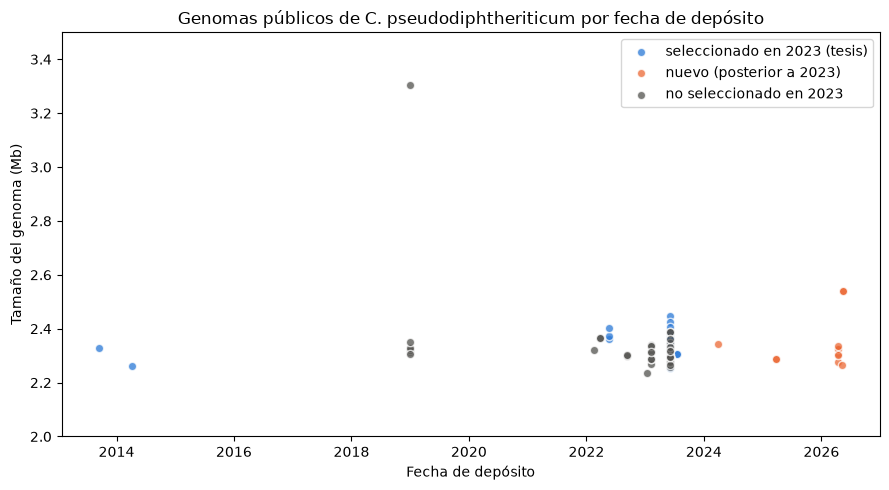

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

genomas = pd.read_excel("genomas_actualizados.xlsx")

colores = {
    "seleccionado en 2023 (tesis)": "#2a78d6",
    "nuevo (posterior a 2023)": "#eb6834",
    "no seleccionado en 2023": "#52514e",
}

fig, ax = plt.subplots(figsize=(9, 5))
for categoria, color in colores.items():
    sub = genomas[genomas["categoria"] == categoria]
    ax.scatter(sub["fecha_release"], sub["tamaño_mb"], color=color, label=categoria, alpha=0.75, edgecolor="white")

ax.set_ylim(2.0, 3.5)
ax.set_xlabel("Fecha de depósito")
ax.set_ylabel("Tamaño del genoma (Mb)")
ax.set_title("Genomas públicos de C. pseudodiphtheriticum por fecha de depósito")
ax.legend()
plt.tight_layout()
plt.savefig("genomas_dispersion.png", dpi=150, bbox_inches="tight")
plt.show()

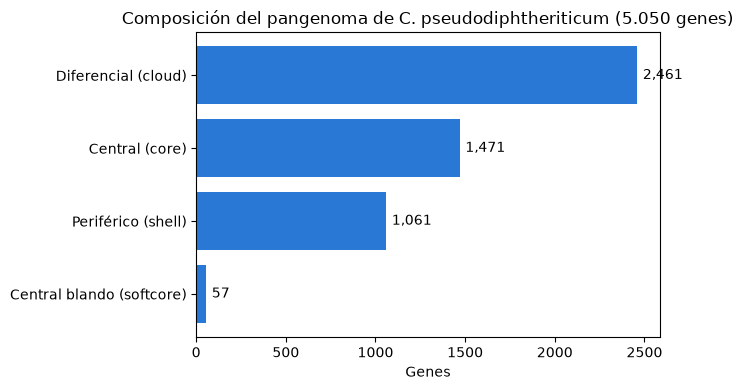

In [10]:
pangenoma = pd.read_excel("pangenoma_composicion.xlsx").sort_values("genes")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(pangenoma["componente"], pangenoma["genes"], color="#2a78d6")
for i, valor in enumerate(pangenoma["genes"]):
    ax.text(valor + 30, i, f"{valor:,}", va="center")
ax.set_xlabel("Genes")
ax.set_title("Composición del pangenoma de C. pseudodiphtheriticum (5.050 genes)")
plt.tight_layout()
plt.savefig("pangenoma_barras.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusión

**Pregunta:** ¿cuánto creció el conocimiento genómico público de *C. pseudodiphtheriticum*
desde mi estudio original (2023), y qué agrega esa actualización?

**Punto de partida (tesis, 2023):** 66 genomas depositados en GenBank, de los cuales
seleccioné 29 de alta calidad para el análisis de pangenoma (5.050 genes, con un
genoma central de 1.471).

**Resultado de esta actualización, con la API de NCBI Datasets:** hoy hay **80 genomas**
depositados (contando una sola vez cada ensamblado — GenBank y RefSeq pueden llevar
accesiones distintas para el mismo genoma, y no filtrar por eso duplicaba el conteo).
De esos 80, **12 son nuevos** desde la fecha más reciente entre mis 29 cepas
originales (21/07/2023).

**Dos observaciones que surgieron del propio dato, no buscadas de antemano:**
- Dos cepas nuevas (LaCa_243, LaCa_244) tienen genomas de ~2,54 Mb, más grandes que
  cualquiera de las 29 originales.
- Una cepa de 2019, no seleccionada en el estudio original, tiene un genoma de
  ~3,3 Mb — bastante por encima del rango típico de la especie (~2,3 Mb). Podría ser
  una cepa real más grande o un ensamblado de menor calidad; no se investigó más a
  fondo acá.

**El contenido de G+C se mantiene mucho más conservado que el tamaño del genoma**
entre las 80 cepas — coherente con que sea una característica taxonómica estable de
la especie.

**La composición del pangenoma** (central: 1.471 · central blando: 57 · periférico:
1.061 · diferencial: 2.461) se muestra tal cual está publicada en la tesis — no se
recalculó con las cepas nuevas en este notebook.

Los gráficos completos, interactivos, están en el dashboard de Tableau Public
enlazado en el perfil de LinkedIn.